# torch-cnmf Inference Tutorial

This notebook demonstrates how to run torch-cnmf on the PBMC3k dataset from scanpy.

Steps:
1. Load data
2. Prepare (normalize, select high-variance genes)
3. Factorize (run NMF)
4. Combine replicates
5. Select K
6. Consensus
7. Save results to MuData

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata
import muon
import os
import torch

from torch_cnmf import cNMF

/home/users/ymo/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Check GPU availability
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

CUDA Available: False
CUDA Version: 12.4
Number of GPUs: 0


## 1. Load Data

In [3]:
adata = sc.datasets.pbmc3k()
adata

100%|██████████| 5.58M/5.58M [00:02<00:00, 2.55MB/s]


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [4]:
# Save counts to h5ad for cNMF input
counts_fn = "example_output/pbmc3k.h5ad"
os.makedirs("example_output", exist_ok=True)
adata.write(counts_fn)

## 2. Set Parameters

In [5]:
# NMF parameters
n_iter = 10
num_highvar_genes = 2000
K = [5, 7, 10]
seed = 14
beta_loss = "frobenius"
init = "random"
algo = "halsvar"
mode = "batch"
tol = 1e-7
use_gpu = True

# Batch mode parameters
batch_max_epoch = 500
batch_hals_tol = 0.005
batch_hals_max_iter = 1000

# Minibatch mode parameters
minibatch_max_epoch = 200
minibatch_size = 5000
minibatch_max_iter = 1000
minibatch_usage_tol = 0.005
minibatch_spectra_tol = 0.005
minibatch_shuffle = True

# Refit parameters
sk_cd_refit = True

# Consensus parameters
density_thresholds = [2.0]

# Paths
output_directory = "example_output/cNMF"
run_name = "pbmc_test"

## 3. Prepare

In [6]:
cnmf_obj = cNMF(output_dir=output_directory, name=run_name)

In [7]:
cnmf_obj.prepare(
    counts_fn=counts_fn,
    components=K,
    n_iter=n_iter,
    num_highvar_genes=num_highvar_genes,
    seed=seed,
    beta_loss=beta_loss,
    init=init,
    algo=algo,
    mode=mode,
    tol=tol,
    use_gpu=use_gpu,
    alpha_usage=0.0,
    alpha_spectra=0.0,
    l1_ratio_usage=0.0,
    l1_ratio_spectra=0.0,
    fp_precision="float",
    batch_max_epoch=batch_max_epoch,
    batch_hals_tol=batch_hals_tol,
    batch_hals_max_iter=batch_hals_max_iter,
    minibatch_max_epoch=minibatch_max_epoch,
    minibatch_size=minibatch_size,
    minibatch_max_iter=minibatch_max_iter,
    minibatch_usage_tol=minibatch_usage_tol,
    minibatch_spectra_tol=minibatch_spectra_tol,
    minibatch_shuffle=minibatch_shuffle,
    sk_cd_refit=sk_cd_refit,
)

Number of genes with zero variance: 16104
Genes with zero variance removed: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'RP11-34P13.14', 'RP11-34P13.9', 'RP4-669L17.10', 'OR4F29', 'RP4-669L17.2', 'RP5-857K21.15', 'RP5-857K21.1', 'RP5-857K21.2', 'RP5-857K21.3', 'RP5-857K21.4', 'RP5-857K21.5', 'OR4F16', 'RP11-206L10.3', 'RP11-206L10.5', 'RP11-206L10.4', 'AL669831.1', 'AL645608.2', 'RP11-54O7.16', 'RP11-54O7.1', 'RP11-54O7.2', 'RP11-54O7.3', 'AL645608.1', 'C1orf170', 'RP11-54O7.18', 'RNF223', 'RP11-465B22.5', 'RP11-465B22.8', 'TTLL10-AS1', 'TTLL10', 'SCNN1D', 'RP4-758J18.13', 'RP4-758J18.7', 'TMEM88B', 'RP4-758J18.10', 'VWA1', 'TMEM240', 'RP11-345P4.7', 'CALML6', 'C1orf222', 'RP11-547D24.1', 'GABRD', 'RP11-547D24.3', 'RP11-181G12.5', 'RP11-181G12.4', 'AL589739.1', 'RP3-395M20.2', 'RP3-395M20.3', 'HES5', 'RP3-395M20.7', 'RP13-436F16.1', 'RP11-740P5.2', 'RP11-740P5.3', 'ACTRT2', 'LINC00982', 'RP1-163G9.2', 'RP11-22L13.1', 'ARHGEF16', 'RP11-168F9.2', 'RP11-46F15.2', 'R

## 4. Factorize

In [8]:
cnmf_obj.factorize(total_workers=1, skip_completed_runs=True)

[Worker 0]. Starting task 0.
CUDA is not available on your machine. Use CPU mode instead.
 niter=10, loss=2247.506674072404.
 niter=20, loss=2247.4657811633083.
 niter=30, loss=2247.465030317491.
 niter=40, loss=2247.465016412936.
    Converged after 40 iteration(s).
[Worker 0]. Starting task 1.
CUDA is not available on your machine. Use CPU mode instead.
 niter=10, loss=2249.182143024437.
 niter=20, loss=2248.7284462557946.
 niter=30, loss=2247.9757699984225.
 niter=40, loss=2247.473998737249.
 niter=50, loss=2247.4651415539242.
 niter=60, loss=2247.465016412936.
    Converged after 60 iteration(s).
[Worker 0]. Starting task 2.
CUDA is not available on your machine. Use CPU mode instead.
 niter=10, loss=2247.689633267903.
 niter=20, loss=2247.4682144582157.
 niter=30, loss=2247.4651971721387.
 niter=40, loss=2247.4650442220454.
    Converged after 40 iteration(s).
[Worker 0]. Starting task 3.
CUDA is not available on your machine. Use CPU mode instead.
 niter=10, loss=2249.40151762641

## 5. Combine

In [9]:
cnmf_obj.combine()

Combining factorizations for k=5.
Combining factorizations for k=7.
Combining factorizations for k=10.


## 6. K Selection

Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed


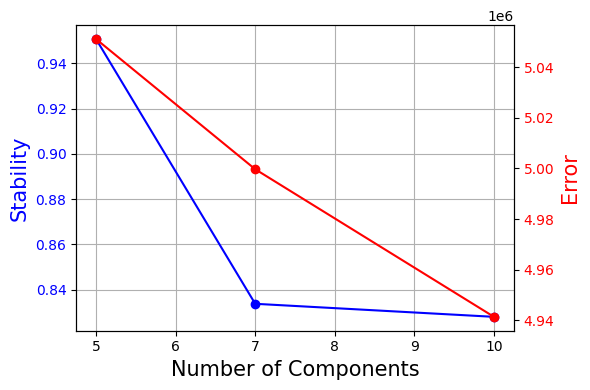

In [10]:
cnmf_obj.k_selection_plot()

## 7. Consensus

Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed
Using sklearn nmf coordinate descent to refit
sklearn refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Using sklearn nmf coordinate descent to refit
sklearn refit completed


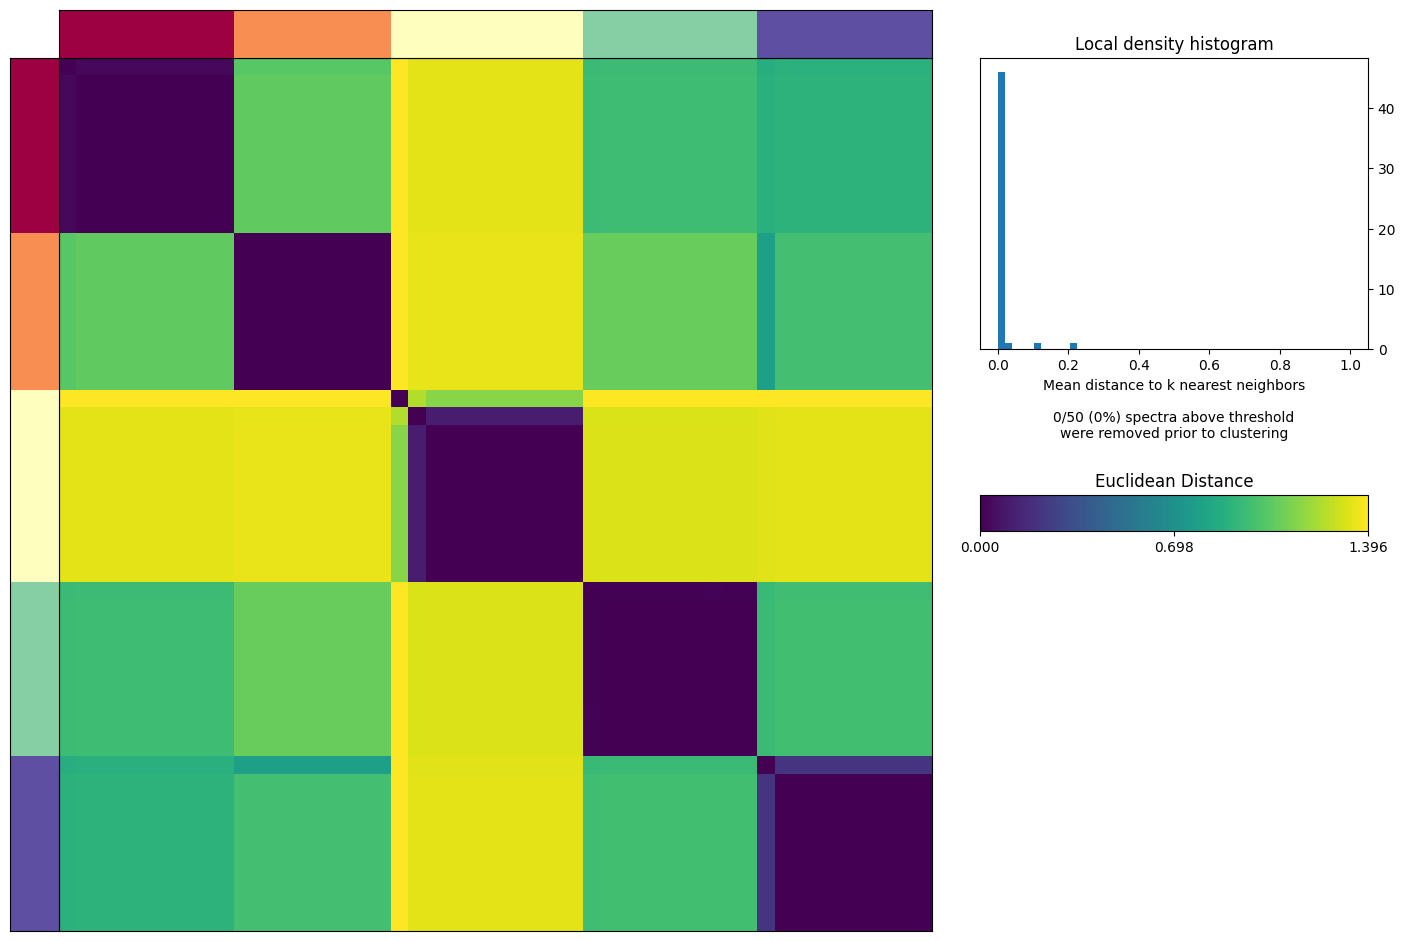

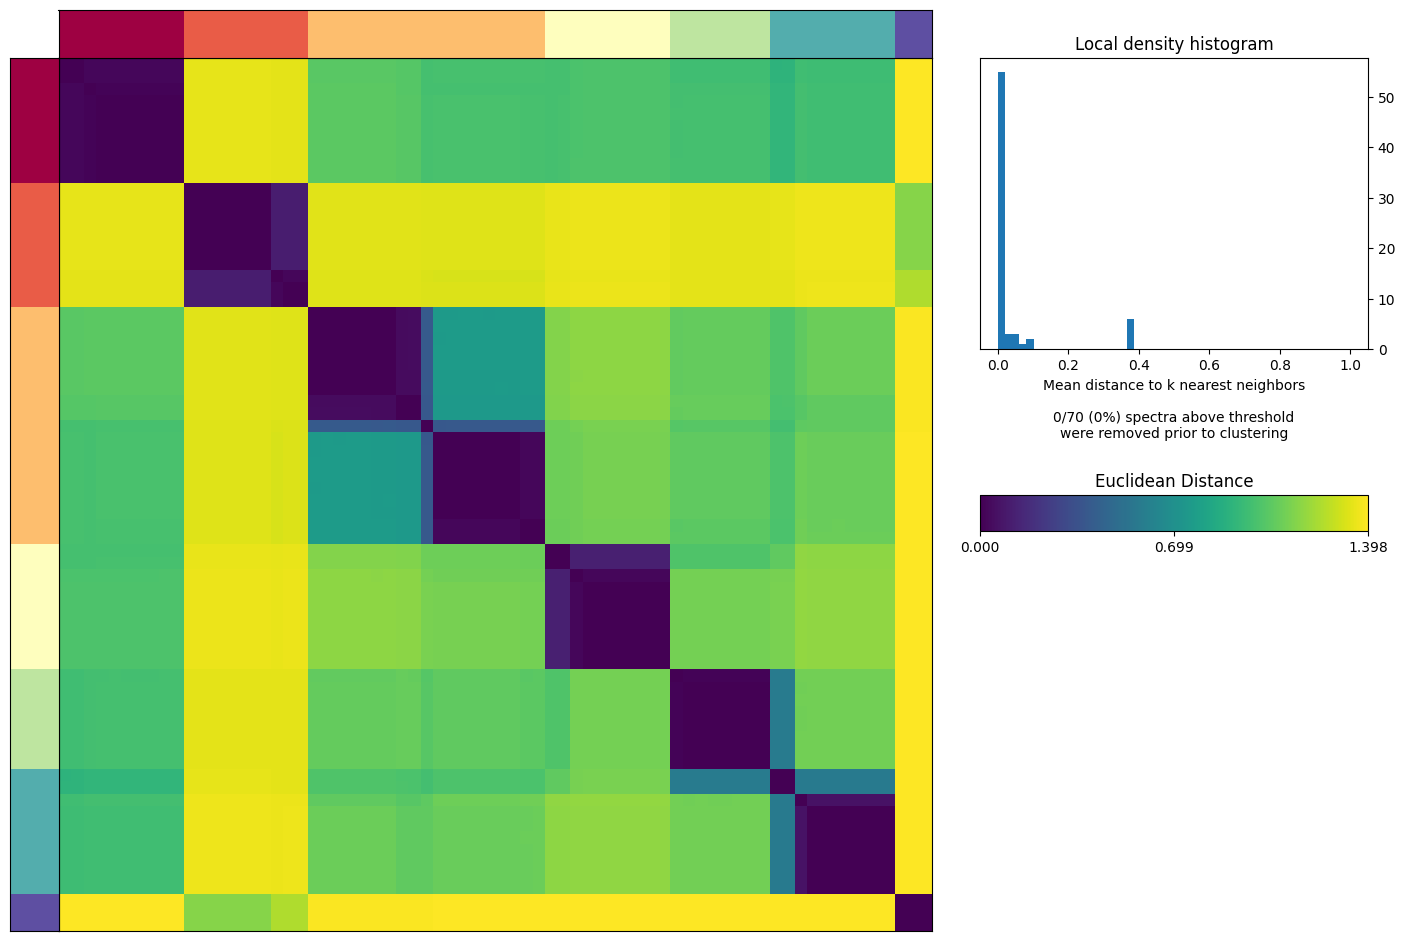

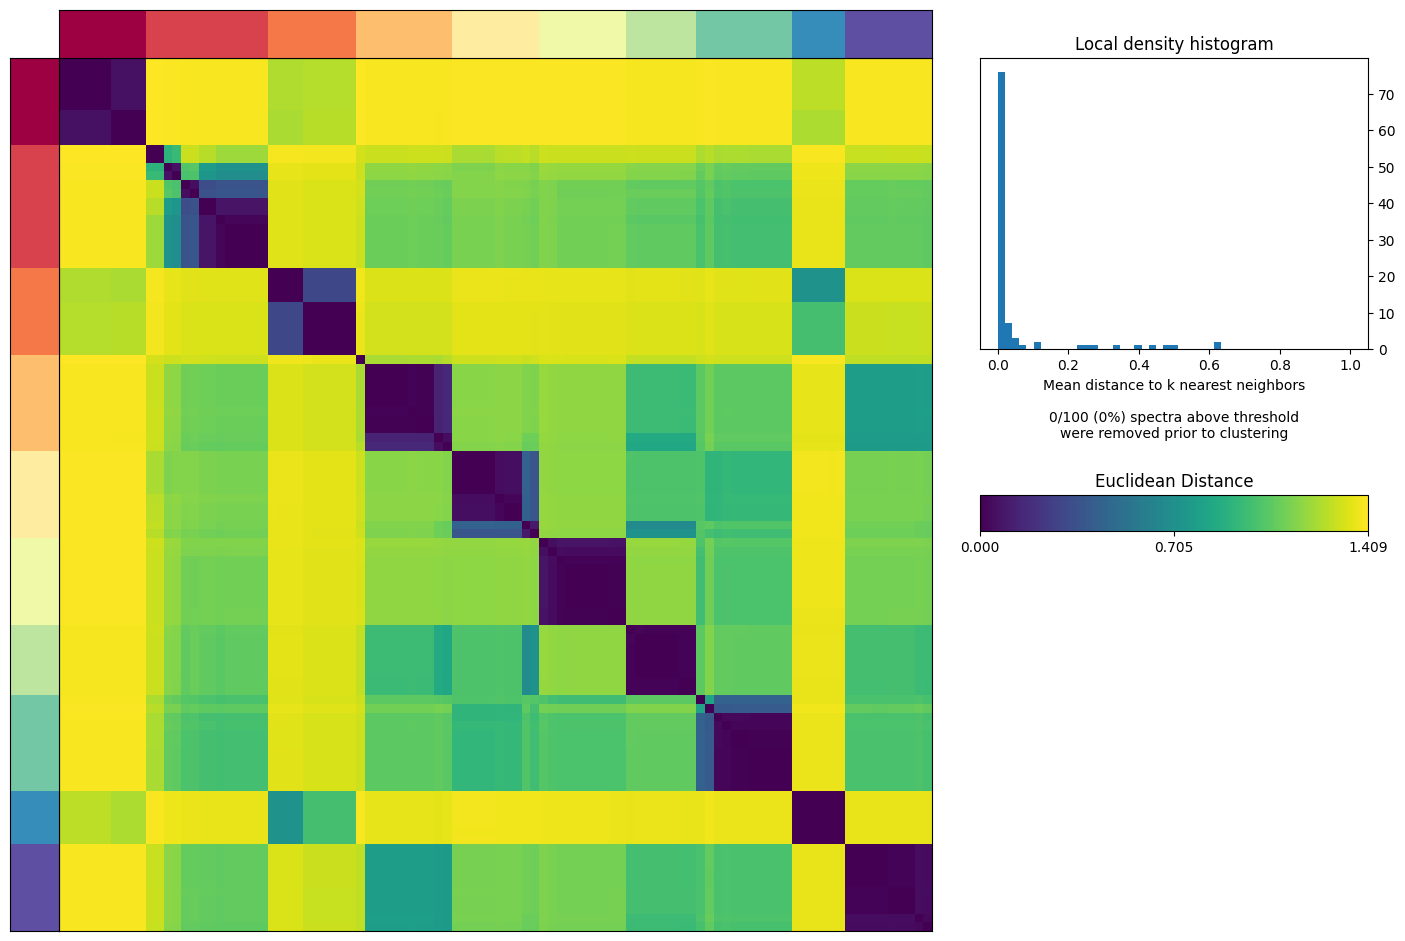

In [11]:
for k in K:
    for thresh in density_thresholds:
        cnmf_obj.consensus(k=k, density_threshold=thresh, show_clustering=True)

## 8. Load and Visualize Results

In [ ]:
selected_K = 7
selected_thresh = 2.0
thresh_str = str(selected_thresh).replace(".", "_")

usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(
    K=selected_K, density_threshold=selected_thresh
)
usage_norm.columns = [f"Usage_{i}" for i in usage_norm.columns]
usage_norm.head()

In [ ]:
topgenes.head(20)

## 9. UMAP Visualization

In [ ]:
adata = sc.read(counts_fn)

# Get high-variance genes used by cNMF
hvgs_file = os.path.join(output_directory, run_name, f"{run_name}.overdispersed_genes.txt")
hvgs = open(hvgs_file).read().split("\n")
hvgs = [g for g in hvgs if g]  # remove empty strings

# Normalize and process
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
adata.raw = sc.pp.log1p(adata.copy(), copy=True)
adata = adata[:, hvgs]
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=15)
sc.tl.umap(adata)

In [ ]:
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how="left", left_index=True, right_index=True)
sc.pl.umap(adata, color=usage_norm.columns, use_raw=True, ncols=3, vmin=0, vmax=1)

## 10. Save Results to MuData

In [ ]:
for thresh in density_thresholds:
    thresh_str = str(thresh).replace(".", "_")
    for k in K:
        # Load consensus usages and spectra
        scores = pd.read_csv(
            f"{output_directory}/{run_name}/{run_name}.usages.k_{k}.dt_{thresh_str}.consensus.txt",
            sep="\t", index_col=0,
        )
        loadings = pd.read_csv(
            f"{output_directory}/{run_name}/{run_name}.spectra.k_{k}.dt_{thresh_str}.consensus.txt",
            sep="\t", index_col=0,
        )

        # Save as plain text
        loading_dir = f"{output_directory}/{run_name}/loading"
        os.makedirs(loading_dir, exist_ok=True)
        scores.to_csv(f"{loading_dir}/cNMF_scores_{k}_{thresh}.txt", sep="\t")
        loadings.T.to_csv(f"{loading_dir}/cNMF_loadings_{k}_{thresh}.txt", sep="\t")

        # Build AnnData for programs
        adata_tpm = sc.read(
            f"{output_directory}/{run_name}/cnmf_tmp/{run_name}.tpm.h5ad"
        )
        adata_tpm.var_names_make_unique()
        adata_tpm.obs_names_make_unique()

        prog_data = anndata.AnnData(X=scores.values, obs=adata_tpm.obs)
        prog_data.varm["loadings"] = loadings.values
        prog_data.uns["var_names"] = loadings.columns.values

        prog_dir = f"{output_directory}/{run_name}/prog_data"
        os.makedirs(prog_dir, exist_ok=True)
        prog_data.write(f"{prog_dir}/NMF_{k}_{thresh_str}.h5ad")

        # Build MuData
        mdata = muon.MuData({"rna": adata_tpm, "cNMF": prog_data})
        adata_dir = f"{output_directory}/{run_name}/adata"
        os.makedirs(adata_dir, exist_ok=True)
        mdata.write(f"{adata_dir}/cNMF_{k}_{thresh_str}.h5mu")

        print(f"Saved k={k}, threshold={thresh}")